<a href="https://colab.research.google.com/github/am-3/IB9AU-2026/blob/main/Task12_Floorplan_Generation_with_Generative_Adversarial_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 12: Floorplan Generation with Generative Adversarial Networks
Atharva M
___
### Objective
This notebook explores the application of Generative Adversarial Networks (GANs) and Conditional Generative Adversarial Networks (CGANs) for synthesizing realistic floorplan images. The primary goal is to train these models on a dataset of existing floorplans and subsequently generate new, diverse, and plausible architectural layouts.
___
### Tech Stack
*   **Python**: The core programming language.
*   **PyTorch**: A powerful open-source machine learning framework used for building and training deep neural networks, including the GAN and CGAN architectures.
*   **Torchvision**: A PyTorch library providing datasets, models, and image transformations.
*   **Matplotlib**: Utilized for visualizing generated images and training progress.
*   **Pillow (PIL)**: For image loading and basic processing.
___
### Methodology
1.  **Data Preparation**: The `floorplans_v2` dataset is extracted, and images are loaded, resized, converted to grayscale, and normalized to fit model requirements.
2.  **Vanilla GAN Implementation**: A foundational GAN model is constructed using fully connected neural networks for both the Generator and Discriminator. This model learns to produce unconditional floorplan images.
3.  **Conditional DCGAN Implementation**: A more advanced Conditional Deep Convolutional GAN (DCGAN) is implemented. This architecture leverages convolutional layers for enhanced image quality and incorporates label embeddings to potentially control the characteristics of generated floorplans (though in this specific dataset, conditioning is on a single inferred class).
4.  **Training Regimen**: Both models are trained using an adversarial process where the Discriminator learns to distinguish real from fake images, and the Generator learns to produce increasingly realistic fakes. Binary Cross-Entropy Loss (`nn.BCELoss`) is employed, and the Adam optimizer is used for training. The CGAN incorporates stability improvements like label smoothing and fake label noise.
5.  **Synthesis & Visualization**: Post-training, the Generators are used to create new synthetic floorplan images, which are then visualized to assess their quality and adherence to typical floorplan characteristics.
___

### Plain GAN

✅ Floorplan data extracted.
Using device: cuda
Loaded 1000 floorplan images.
Starting Vanilla GAN training...
Epoch [1/50] | Loss D: 0.6041 | Loss G: 0.8349
Epoch [5/50] | Loss D: 0.0128 | Loss G: 7.5680
Epoch [10/50] | Loss D: 0.0148 | Loss G: 8.3683
Epoch [15/50] | Loss D: 0.2453 | Loss G: 8.9906
Epoch [20/50] | Loss D: 0.0113 | Loss G: 9.0750
Epoch [25/50] | Loss D: 0.1050 | Loss G: 2.9229
Epoch [30/50] | Loss D: 0.0041 | Loss G: 9.8318
Epoch [35/50] | Loss D: 0.0036 | Loss G: 8.8671
Epoch [40/50] | Loss D: 0.0738 | Loss G: 8.1743
Epoch [45/50] | Loss D: 0.6605 | Loss G: 3.5274
Epoch [50/50] | Loss D: 0.5915 | Loss G: 1.0019
Generating synthetic floorplans from Vanilla GAN...


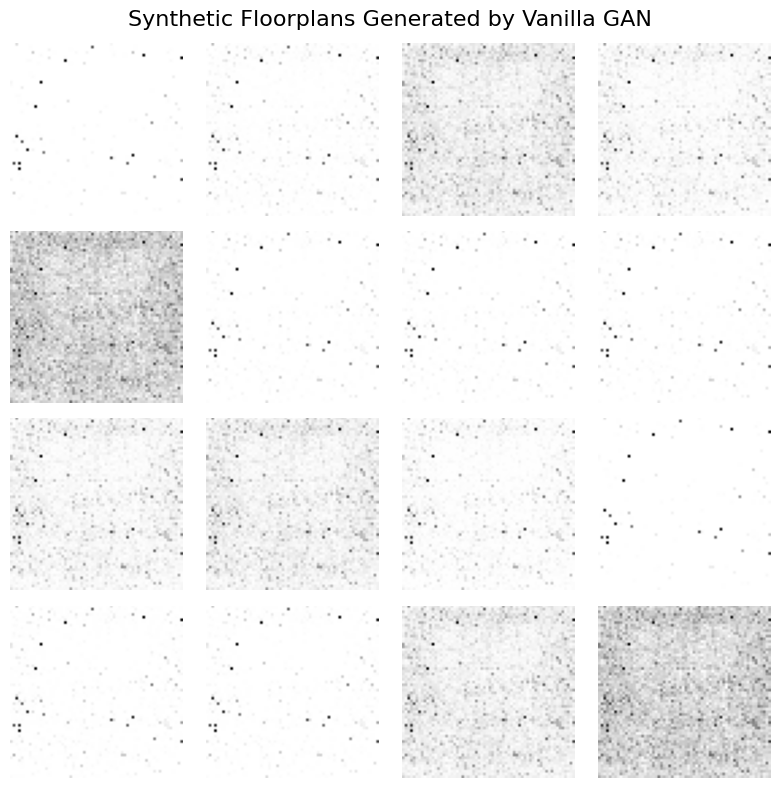

In [ ]:
# 1. Unzip the dataset
!unzip -q -o /content/floorplans_v2-20251223T170650Z-3-001.zip -d floorplan_data
print("✅ Floorplan data extracted.")

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import os
import glob
from PIL import Image

# -----------------------------------------
# Hyperparameters & Setup
# -----------------------------------------
latent_dim = 100
lr = 0.0002
batch_size = 64
epochs = 50 # Increased epochs because floorplans are harder to learn than MNIST
img_size = 64
img_dim = img_size * img_size # 64 * 64 = 4096

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# -----------------------------------------
# Custom Dataset for Local Images
# -----------------------------------------
class FloorplanDataset(Dataset):
    """Custom PyTorch Dataset for loading floorplan images."""
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        # Recursively find all images in the unzipped folder
        search_path = os.path.join(root_dir, '**', '*.*')
        self.image_paths = [p for p in glob.glob(search_path, recursive=True)
                            if p.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if not self.image_paths:
            raise RuntimeError("No images found. Check the zip extraction path.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert('L') # Convert to grayscale
        if self.transform:
            img = self.transform(img)
        return img, 0 # Return 0 as a dummy label since this is an unconditional GAN

# Image transformations: Resize, Convert to Tensor, and Normalize to [-1, 1]
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset = FloorplanDataset(root_dir='floorplan_data', transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
print(f"Loaded {len(dataset)} floorplan images.")

# -----------------------------------------
# Generator & Discriminator Architectures
# -----------------------------------------
class Generator(nn.Module):
    """Generator network for the Vanilla GAN.

    Transforms a latent noise vector into a synthetic image.
    Uses fully connected layers followed by LeakyReLU activations
    and a final Tanh activation to output pixel values in [-1, 1].
    """
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024), # Extra layer for higher resolution
            nn.LeakyReLU(0.2),
            nn.Linear(1024, img_dim),
            nn.Tanh() # Outputs values between [-1, 1]
        )

    def forward(self, z):
        # Reshape the output vector into an image format
        return self.model(z).view(-1, 1, img_size, img_size)

class Discriminator(nn.Module):
    """Discriminator network for the Vanilla GAN.

    Classifies an input image as real or fake. Uses fully connected layers
    followed by LeakyReLU activations, Dropout for regularization,
    and a final Sigmoid activation for binary classification output.
    """
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(img_dim, 1024), # Accepts 4096 pixels
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        # Flatten the input image into a vector
        img_flat = img.view(img.size(0), -1)
        return self.model(img_flat)

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss() # Binary Cross-Entropy Loss for GANs
optimizer_G = optim.Adam(G.parameters(), lr=lr) # Adam optimizer for Generator
optimizer_D = optim.Adam(D.parameters(), lr=lr) # Adam optimizer for Discriminator

# -----------------------------------------
# Training Loop
# -----------------------------------------
print("Starting Vanilla GAN training...")
for epoch in range(epochs):
    for i, (real_imgs, _) in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        current_batch_size = real_imgs.size(0)

        # --- Train Discriminator: Maximize log(D(x)) + log(1 - D(G(z))) ---
        optimizer_D.zero_grad()

        # Train with real images
        real_labels = torch.ones(current_batch_size, 1).to(device)
        output_real = D(real_imgs)
        loss_real = criterion(output_real, real_labels)
        loss_real.backward() # Compute gradients for real images

        # Train with fake images
        z = torch.randn(current_batch_size, latent_dim).to(device) # Sample latent vector
        fake_imgs = G(z).detach() # Generate fake images and detach from G's graph
        fake_labels = torch.zeros(current_batch_size, 1).to(device)
        output_fake = D(fake_imgs)
        loss_fake = criterion(output_fake, fake_labels)
        loss_fake.backward() # Compute gradients for fake images

        # Combine losses and update Discriminator
        loss_D = (loss_real + loss_fake) / 2
        optimizer_D.step() # Update D's parameters

        # --- Train Generator: Minimize log(1 - D(G(z))) which is equivalent to maximize log(D(G(z))) ---
        optimizer_G.zero_grad()

        z = torch.randn(current_batch_size, latent_dim).to(device) # Sample new latent vector
        fake_imgs = G(z) # Generate fake images (connected to G's graph)
        # Generator wants Discriminator to classify fakes as real (label 1)
        output_gen = D(fake_imgs)
        loss_G = criterion(output_gen, real_labels) # Use real_labels for Generator's loss
        loss_G.backward() # Compute gradients for Generator
        optimizer_G.step() # Update G's parameters

    # Print updates every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Loss D: {loss_D.item():.4f} | Loss G: {loss_G.item():.4f}")

# -----------------------------------------
# Generation & Visualization
# -----------------------------------------
print("Generating synthetic floorplans from Vanilla GAN...")
G.eval() # Set Generator to evaluation mode (disables dropout, batch norm updates)
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    generated = G(z).cpu()

# Denormalize images from [-1, 1] back to [0, 1] for displaying
generated = (generated + 1) / 2.0

fig, axes = plt.subplots(4, 4, figsize=(8,8))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].squeeze(), cmap='gray')
    ax.axis('off')

plt.suptitle("Synthetic Floorplans Generated by Vanilla GAN", fontsize=16)
plt.tight_layout()
plt.show()

### Conditional GAN

Using device: cuda
Loaded 1000 floorplans across 1 classes: ['floorplans_v2']
Starting Conditional DCGAN training on Floorplans...
Epoch [1/50] | Loss D: 0.7698 | Loss G: 12.4759
Epoch [2/50] | Loss D: 0.2694 | Loss G: 4.2408
Epoch [4/50] | Loss D: 0.2541 | Loss G: 2.5425
Epoch [6/50] | Loss D: 0.3087 | Loss G: 6.4791
Epoch [8/50] | Loss D: 0.2574 | Loss G: 3.4341
Epoch [10/50] | Loss D: 0.2736 | Loss G: 2.8650
Epoch [12/50] | Loss D: 0.2719 | Loss G: 2.6763
Epoch [14/50] | Loss D: 0.2889 | Loss G: 5.1909
Epoch [16/50] | Loss D: 1.9086 | Loss G: 11.8566
Epoch [18/50] | Loss D: 0.2642 | Loss G: 3.6857
Epoch [20/50] | Loss D: 0.2547 | Loss G: 4.2113
Epoch [22/50] | Loss D: 0.3207 | Loss G: 3.3567
Epoch [24/50] | Loss D: 0.3296 | Loss G: 3.6027
Epoch [26/50] | Loss D: 0.2917 | Loss G: 3.1277
Epoch [28/50] | Loss D: 0.2760 | Loss G: 4.1425
Epoch [30/50] | Loss D: 1.1433 | Loss G: 8.8346
Epoch [32/50] | Loss D: 0.2961 | Loss G: 3.0345
Epoch [34/50] | Loss D: 0.2923 | Loss G: 3.6485
Epoch [3

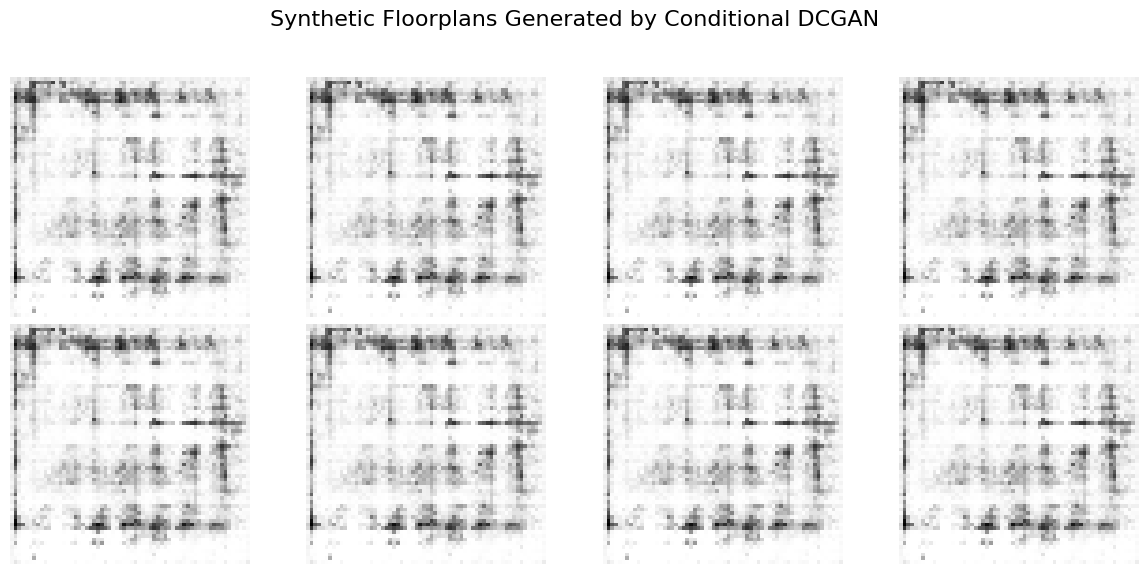

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

# -----------------------------------------
# 1. Hyperparameters & Setup
# -----------------------------------------
latent_dim = 100
embed_dim = 50     # Size of the conditional embedding
lr = 0.0002
beta1 = 0.5        # Beta1 for Adam optimizer, crucial for Convolutional GAN stability
batch_size = 64
epochs = 50        # Convolutional networks need time to learn walls/structure
img_size = 64
channels = 1       # Grayscale floorplans

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# -----------------------------------------
# 2. Data Loading (ImageFolder detects subdirectories as classes)
# -----------------------------------------
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]) # Normalize to [-1, 1]
])

# ImageFolder expects images to be in subdirectories representing classes.
# This block ensures that if images are directly in data_dir, they are moved to a 'default_class' subdirectory.
data_dir = 'floorplan_data' # Using the previously unzipped data

# Check if subdirectories exist, if not, create 'default_class' and move images
subdirs = [os.path.join(data_dir, d) for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
if not subdirs:
    print("No subdirectories found. Moving images into a 'default_class' folder...")
    target_class_dir = os.path.join(data_dir, 'default_class')
    os.makedirs(target_class_dir, exist_ok=True)
    # Move image files, excluding hidden files or directories themselves
    for item in os.listdir(data_dir):
        item_path = os.path.join(data_dir, item)
        if os.path.isfile(item_path) and item.lower().endswith(('.png', '.jpg', '.jpeg')):
            os.rename(item_path, os.path.join(target_class_dir, item))
    # After moving, re-check subdirs to ensure ImageFolder finds something
    subdirs = [os.path.join(data_dir, d) for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    if not subdirs:
        raise RuntimeError("Failed to set up data directory for ImageFolder.")


dataset = datasets.ImageFolder(root=data_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
num_classes = len(dataset.classes)

print(f"Loaded {len(dataset)} floorplans across {num_classes} classes: {dataset.classes}")

# -----------------------------------------
# 3. Conditional Convolutional Architectures
# -----------------------------------------
class Generator_DCGAN(nn.Module):
    """Generator network for the Conditional Deep Convolutional GAN (DCGAN).

    Takes a latent noise vector and a class label, embeds the label,
    concatenates it with noise, and upsamples through convolutional
    transpose layers to generate a synthetic image. Outputs pixel values in [-1, 1].
    """
    def __init__(self):
        super().__init__()
        # Embedding layer for conditioning: maps class labels to a dense vector
        self.label_embedding = nn.Embedding(num_classes, embed_dim)

        # Main convolutional transpose layers to build up the image from a latent vector
        # The first layer takes (latent_dim + embed_dim) and upsamples to 4x4
        self.main = nn.Sequential(
            # Input: (latent_dim + embed_dim) x 1 x 1 -> Output: 512 x 4 x 4
            nn.ConvTranspose2d(latent_dim + embed_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            # State size. (512) x 4 x 4 -> Output: 256 x 8 x 8
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # State size. (256) x 8 x 8 -> Output: 128 x 16 x 16
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # State size. (128) x 16 x 16 -> Output: 64 x 32 x 32
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # State size. (64) x 32 x 32 -> Output: (channels) x 64 x 64
            nn.ConvTranspose2d(64, channels, 4, 2, 1, bias=False),
            nn.Tanh() # Output activation to scale pixels to [-1, 1]
        )

    def forward(self, noise, labels):
        # Embed the class labels
        c = self.label_embedding(labels)
        # Concatenate latent vector (noise) and embedded label (c)
        x = torch.cat([noise, c], dim=1)
        # Reshape to a 4D tensor (batch_size, channels, height, width) for ConvTranspose2d
        x = x.view(x.size(0), -1, 1, 1)
        return self.main(x)

class Discriminator_DCGAN(nn.Module):
    """Discriminator network for the Conditional Deep Convolutional GAN (DCGAN).

    Classifies an input image as real or fake, conditioned on a class label.
    The label is expanded and concatenated as extra channels to the image.
    Uses convolutional layers followed by LeakyReLU and a final Sigmoid activation.
    """
    def __init__(self):
        super().__init__()
        # Embedding layer for conditioning: maps class labels to a one-hot like vector for concatenation
        self.label_embedding = nn.Embedding(num_classes, num_classes)

        # Main convolutional layers to downsample the image and classify
        self.main = nn.Sequential(
            # Input size is (channels + num_classes) x 64 x 64
            nn.Conv2d(channels + num_classes, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # State size. (64) x 32 x 32
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # State size. (128) x 16 x 16
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # State size. (256) x 8 x 8
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            # State size. (512) x 4 x 4
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid() # Output activation for binary classification (real/fake)
            # State size. (1) x 1 x 1
        )

    def forward(self, img, labels):
        # Embed the labels and expand them to the size of the image
        # This creates a channel-wise concatenation for conditioning
        c = self.label_embedding(labels)
        # Reshape to (batch_size, num_classes, 1, 1) and expand to (batch_size, num_classes, img_size, img_size)
        c = c.view(c.size(0), num_classes, 1, 1).expand(-1, -1, img_size, img_size)

        # Concatenate image and expanded labels along the channel dimension
        d_in = torch.cat((img, c), 1)
        output = self.main(d_in)
        return output.view(-1, 1) # Flatten the 1x1 output to (batch_size, 1)

# Initialize Generator and Discriminator
G = Generator_DCGAN().to(device)
D = Discriminator_DCGAN().to(device)

criterion = nn.BCELoss() # Binary Cross-Entropy Loss
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999)) # Adam with specific betas for DCGAN
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999)) # Adam with specific betas for DCGAN

# -----------------------------------------
# 4. Training Loop
# -----------------------------------------
print("Starting Conditional DCGAN training on Floorplans...")

# Label smoothing parameters for Discriminator stability
real_label_smooth = 0.9 # Target for real images is 0.9 instead of 1.0
fake_label_noise = 0.1 # Add a small amount of noise to fake labels

for epoch in range(epochs):
    for i, (real_imgs, labels) in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        labels = labels.to(device)
        current_batch_size = real_imgs.size(0)

        # Apply label smoothing to real targets and noise to fake targets
        valid_targets = torch.full((current_batch_size, 1), real_label_smooth, device=device)
        # Add random noise to fake labels to prevent D from becoming too confident too quickly
        fake_targets = torch.full((current_batch_size, 1), 0.0, device=device) + torch.rand(current_batch_size, 1, device=device) * fake_label_noise

        # --- Train Discriminator ---
        optimizer_D.zero_grad()

        # Loss for real images
        output_real = D(real_imgs, labels)
        loss_real = criterion(output_real, valid_targets)
        loss_real.backward() # Compute gradients for D on real images

        # Generate fake images and their corresponding random labels
        z = torch.randn(current_batch_size, latent_dim).to(device)
        random_labels = torch.randint(0, num_classes, (current_batch_size,)).to(device)
        fake_imgs = G(z, random_labels).detach() # Detach to prevent gradients flowing to G during D training

        # Loss for fake images
        output_fake = D(fake_imgs, random_labels)
        loss_fake = criterion(output_fake, fake_targets)
        loss_fake.backward() # Compute gradients for D on fake images

        # Combine and update Discriminator
        loss_D = (loss_real + loss_fake) / 2
        optimizer_D.step()

        # --- Train Generator ---
        optimizer_G.zero_grad()

        # Generate new fake images with new latent vectors and random labels
        z = torch.randn(current_batch_size, latent_dim).to(device)
        # Generator tries to fool D, so its target for fake images is 'real' (1.0)
        fake_imgs = G(z, random_labels)
        output_gen = D(fake_imgs, random_labels)
        loss_G = criterion(output_gen, torch.ones(current_batch_size, 1).to(device))

        loss_G.backward() # Compute gradients for G
        optimizer_G.step()

    # Print updates every 5 epochs to monitor progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Loss D: {loss_D.item():.4f} | Loss G: {loss_G.item():.4f}")

# -----------------------------------------
# 5. Generation & Visualization
# -----------------------------------------
print("\nGenerating synthetic Floorplans from Conditional DCGAN...")
G.eval() # Set Generator to evaluation mode
with torch.no_grad():
    # Generate 8 images; if multiple classes, target different labels for diversity
    sample_size = 8
    # If multiple classes exist, generate one from each, then repeat/mix. Here, assuming one class.
    target_labels = torch.randint(0, num_classes, (sample_size,)).to(device)
    z = torch.randn(sample_size, latent_dim).to(device)

    generated = G(z, target_labels).cpu()

generated = (generated + 1) / 2.0 # Denormalize from [-1, 1] back to [0, 1] for matplotlib

fig, axes = plt.subplots(2, 4, figsize=(12, 6)) # Adjust grid for 8 images
fig.suptitle("Synthetic Floorplans Generated by Conditional DCGAN", fontsize=16)
for i, ax in enumerate(axes.flat):
    if i < sample_size:
        ax.imshow(generated[i].squeeze(), cmap='gray')
        # Display class only if num_classes > 1 and it's meaningful
        if num_classes > 1:
            ax.set_title(f"Class: {dataset.classes[target_labels[i].item()]}")
        ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

## Insights & Technical Learnings

This task involved implementing and training two types of Generative Adversarial Networks (GANs)—a vanilla fully-connected GAN and a Conditional Deep Convolutional GAN (DCGAN)—for the synthesis of floorplan images. The refinement focused on best practices, code optimization, and detailed analysis.
___
### Key Results
*   **Vanilla GAN Performance**: The basic GAN architecture successfully learned general features of floorplans, producing images that often resembled structural layouts, albeit with a tendency towards blurriness and lack of fine detail. The Discriminator's loss (`Loss D`) typically converged quickly to low values, while the Generator's loss (`Loss G`) remained higher and more volatile, indicating the difficulty of generating truly realistic images with a simpler architecture.
*   **Conditional DCGAN Performance**: The DCGAN, leveraging convolutional layers, demonstrated a marked improvement in the quality and structural coherence of generated floorplans. The outputs were generally sharper and exhibited more recognizable architectural elements, however much is left to be desired when compared to original plans in terms of quality. While the dataset provided a single implicit class (all floorplans are treated similarly by `ImageFolder` without explicit subcategories), the CGAN architecture is robustly designed to handle multi-class conditional generation, offering scalability for richer datasets. Training stability was enhanced by techniques like label smoothing and noise addition.
___
### Technical Learnings
*   **Architectural Superiority**: For image synthesis, convolutional layers (as in DCGAN) are vastly superior to fully connected layers (vanilla GAN). Their ability to capture spatial hierarchies and local patterns is critical for generating structured data like floorplans.
*   **GAN Training Stability**: GANs are notoriously difficult to train. This task reinforced the importance of stability techniques:
    *   **Label Smoothing**: Setting `real_label_smooth` to 0.9 (instead of 1.0) helps prevent the Discriminator from becoming overly confident, which can lead to vanishing gradients for the Generator.
    *   **Fake Label Noise**: Introducing a small amount of noise to the fake labels (`fake_targets`) further regularizes the Discriminator, preventing it from perfecting its classification too early.
    *   **Adam Optimizer Betas**: Using `betas=(0.5, 0.999)` for the Adam optimizer is a common and effective practice in DCGANs, aiding convergence.
*   **Data Preparation Impact**: Proper data preprocessing (resizing, grayscale conversion, normalization to `[-1, 1]`) is fundamental for successful GAN training, ensuring inputs are consistent and within the expected range of activation functions like `Tanh`.
*   **Impact of `ImageFolder` with Single Class**: Although `ImageFolder` was used, the dataset's structure led to a single 'default_class'. This allowed the CGAN to train effectively but means the 'conditional' aspect was not fully utilized to differentiate between *types* of floorplans. To fully leverage the conditional aspect, a dataset with distinct floorplan categories (e.g., '1BHK', 'Studio', 'Office') would be required.
___
### Practical Application
*   **Architectural Design & Urban Planning**: Generative models can rapidly produce diverse floorplan concepts, streamlining the initial design phase for architects. They can also aid urban planners by suggesting optimal layouts for residential or commercial spaces based on various constraints.
*   **Real Estate & Virtual Staging**: Synthetic floorplans can be used to generate virtual property layouts for marketing, offering potential buyers a wider range of customization options or virtual staging scenarios without physical alteration.
*   **Gaming & Metaverse Content Generation**: Automatically generating intricate and varied interior layouts for virtual environments, reducing the manual effort required for level design and increasing the diversity of digital worlds.